In [19]:
import pandas as pd
import numpy as np
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

In [28]:
data_train = pd.read_csv("../../../dataset/Spotify_train_preprocesado_clasificacion.csv")

data_test = pd.read_csv("../../../dataset/Spotify_test_preprocesado_clasificacion.csv")

df_train = data_train.copy()
df_test = data_test.copy()

print("Dataset de entrenamiento: ")
display(df_train.head())


print("Dataset de pruebas: ")
display(df_test.head())

Dataset de entrenamiento: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.360656,0.407609,0.005418,...,-0.557598,0.751125,-0.804229,0.532848,-0.562123,-0.436477,1.542740,-0.147610,-0.695300,1
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.360656,0.100464,-0.034422,...,-0.017461,0.751125,-0.785413,0.623235,-0.606882,-0.678120,1.183864,0.437714,-0.191994,0
2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.927115,-1.881489,0.216573,...,0.430609,0.751125,-0.519639,-0.618079,-0.580263,-0.985860,-1.305115,0.437984,0.625209,2
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.360656,1.746296,0.336094,...,0.571210,-1.331337,-0.500823,-0.710274,-0.606882,-0.635477,-0.506326,0.064335,-0.879964,0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,-0.360656,0.726344,-1.795371,...,-2.390784,-1.331337,1.124396,1.430692,1.793755,-0.671013,1.195440,2.664353,-0.772929,2


Dataset de pruebas: 


,bin__track_genre_0,bin__track_genre_1,bin__track_genre_2,bin__track_genre_3,bin__track_genre_4,bin__track_genre_5,bin__track_genre_6,ord__duration_category,num__danceability,num__energy,...,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,num__tempo,num__duration_min,popularity_category
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.927115,-1.452645,-1.914892,...,-2.318107,0.751125,-0.700742,1.813330,1.793755,-0.700153,-1.619613,-0.133029,1.330330,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,1.798453,0.626930,...,1.478109,0.751125,0.865678,-0.675324,-0.606764,1.390062,1.450127,-0.406397,-0.528812,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.360656,0.639416,0.224541,...,0.842404,0.751125,-0.199770,-0.940037,-0.606785,-0.724317,1.303489,2.353574,-0.550148,0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.648427,-0.067596,0.754419,...,0.438615,0.751125,2.126046,1.707878,-0.606882,2.409939,0.292462,-1.350621,-1.566635,1
4,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.927115,0.830657,1.093063,...,1.257701,0.751125,-0.380872,-0.942719,1.793755,-1.048403,1.006355,0.096426,1.158399,0


In [ ]:
# Separación de variables predictoras y objetivo
X_train = df_train.drop(
    columns=["popularity_category"]
)

y_train = df_train[
    "popularity_category"
]

X_test = df_test.drop(
    columns=["popularity_category"]
)

y_test = df_test[
    "popularity_category"
]

In [22]:
# Crear modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [23]:
# Predicciones sobre el conjunto de prueba
y_pred = rf_model.predict(X_test)

In [24]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Muy baja",
            "Baja",
            "Media",
            "Alta",
            "Muy alta"
        ]
    )
)

Accuracy:  0.9935
Precision: 0.9935
Recall:    0.9935
F1-score:  0.9935

Reporte de clasificación:
              precision    recall  f1-score   support

    Muy baja       0.99      0.99      0.99     26966
        Baja       1.00      0.99      1.00     26966
       Media       0.99      0.99      0.99     26966
        Alta       0.99      0.99      0.99     26966
    Muy alta       1.00      1.00      1.00     26966

    accuracy                           0.99    134830
   macro avg       0.99      0.99      0.99    134830
weighted avg       0.99      0.99      0.99    134830



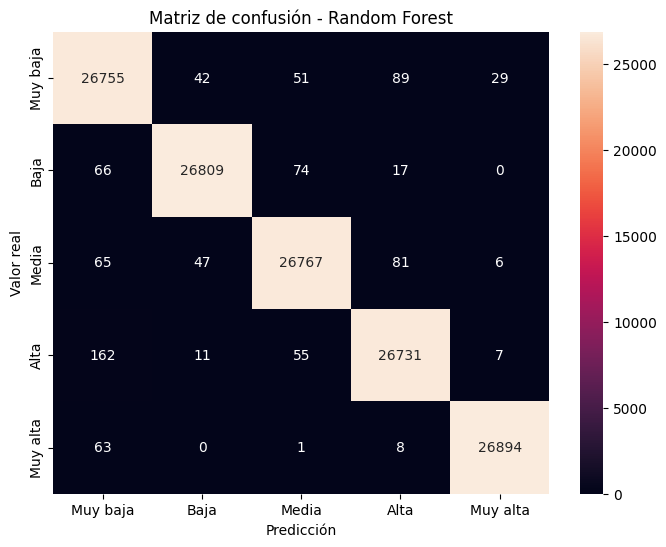

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Muy baja",
        "Baja",
        "Media",
        "Alta",
        "Muy alta"
    ],
    yticklabels=[
        "Muy baja",
        "Baja",
        "Media",
        "Alta",
        "Muy alta"
    ]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# Importancia de las variables

In [26]:
importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

importancias = importancias.sort_values(
    by="importance",
    ascending=False
)

print(importancias.head(15))

                  feature  importance
14      num__acousticness    0.074745
8       num__danceability    0.072766
9             num__energy    0.071168
17           num__valence    0.068784
19      num__duration_min    0.067653
11          num__loudness    0.067310
18             num__tempo    0.063814
13       num__speechiness    0.063008
16          num__liveness    0.061141
15  num__instrumentalness    0.053557
10               num__key    0.045650
4      bin__track_genre_4    0.039813
3      bin__track_genre_3    0.038204
1      bin__track_genre_1    0.037052
5      bin__track_genre_5    0.036595


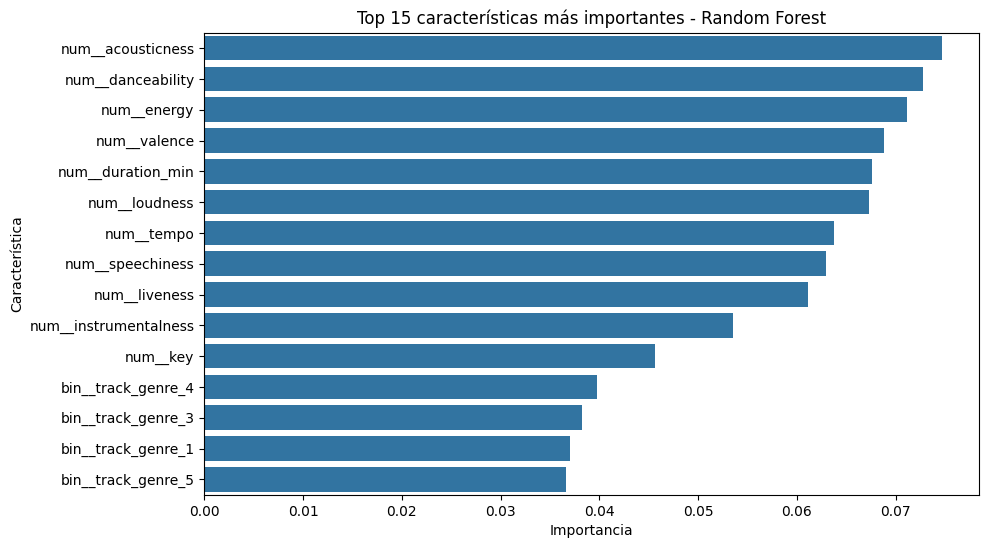

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importancias.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 características más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Característica")
plt.show()